# 🏢 Bloyce's Protocol — Strict Complaint Processor
## NormalObjects Lab 2 | LangGraph Structured Workflow

This notebook implements a structured, rule-based complaint processing system for the Downside Up Complaint Bureau using LangGraph. Unlike the freeform LangChain agent (Lab 1), this system enforces a strict workflow:

```
intake → validate → investigate → resolve → close
```

Every step is mandatory. No complaint can skip steps.

## Step 1: Install & Import Dependencies

In [1]:
# Install required packages
%pip install -q langgraph langchain langchain-openai python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
from datetime import datetime
from typing import TypedDict, List, Optional

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, END

load_dotenv()

# Initialise LLM
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise EnvironmentError("OPENAI_API_KEY not found. Please add it to a .env file.")

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print("✅ LLM initialised successfully")

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ LLM initialised successfully


## Step 2: Define the Complaint State

All data flows through a `ComplaintState` TypedDict. Every node reads from and writes back to this shared structure.

In [2]:
class ComplaintState(TypedDict):
    """Shared state that travels through every node in the workflow."""
    # Input
    complaint: str

    # Populated by intake
    category: str          # portal | monster | psychic | environmental | other
    missing_details: List[str]  # Any required fields that are absent

    # Populated by validate
    is_valid: bool
    validation_notes: str

    # Populated by investigate
    evidence: str
    investigation_summary: str

    # Populated by resolve
    resolution: str
    effectiveness_rating: str   # high | medium | low
    requires_escalation: bool

    # Populated by close
    closed_at: str
    outcome: str
    follow_up_required: bool

    # Audit trail
    workflow_path: List[str]
    status: str
    rejection_reason: Optional[str]

print("✅ ComplaintState defined")

✅ ComplaintState defined


## Step 3: Define Workflow Nodes

Each node corresponds to one mandatory stage of Bloyce's Protocol.

In [3]:
# ─────────────────────────────────────────────
# NODE 1: INTAKE
# Parse and categorise the incoming complaint.
# ─────────────────────────────────────────────

def intake_node(state: ComplaintState) -> ComplaintState:
    """Step 1: Intake — parse and categorise the complaint."""
    print("\n" + "="*60)
    print("[INTAKE] Processing complaint...")
    print("="*60)

    complaint = state["complaint"]

    # ── Categorise ──
    cat_prompt = f"""You are the intake officer for the Downside Up Complaint Bureau.
Categorise the complaint below into EXACTLY ONE of these categories:
- portal: Issues with portal timing, location, or behaviour
- monster: Issues with creature behaviour (demogorgons, etc.)
- psychic: Issues with psychic abilities or limitations
- environmental: Issues with electricity, weather, or physical environment
- other: Anything else

Complaint: {complaint}

Reply with ONLY the single category word (portal / monster / psychic / environmental / other)."""

    cat_response = llm.invoke([HumanMessage(content=cat_prompt)])
    category = cat_response.content.strip().lower()
    if category not in {"portal", "monster", "psychic", "environmental", "other"}:
        category = "other"

    # ── Check for missing details ──
    detail_prompt = f"""Check this complaint for the four required fields: who, what, when, where.
List any that are MISSING or too vague to act on. If all are present, reply with 'none'.

Complaint: {complaint}

Reply with a comma-separated list of missing fields, e.g. 'when, where' — or 'none' if complete."""

    detail_response = llm.invoke([HumanMessage(content=detail_prompt)])
    raw = detail_response.content.strip().lower()
    missing_details = [] if raw == "none" else [d.strip() for d in raw.split(",")]

    print(f"  Category     : {category}")
    print(f"  Missing      : {missing_details if missing_details else 'nothing'}")

    return {
        **state,
        "category": category,
        "missing_details": missing_details,
        "workflow_path": state.get("workflow_path", []) + ["intake"],
        "status": "intake_complete",
    }


print("✅ intake_node defined")

✅ intake_node defined


In [4]:
# ─────────────────────────────────────────────
# NODE 2: VALIDATE
# Apply category-specific validation rules.
# ─────────────────────────────────────────────

VALIDATION_RULES = {
    "portal": "must reference specific location or timing anomalies",
    "monster": "must describe creature behaviour or interactions",
    "psychic": "must reference specific ability limitations or malfunctions",
    "environmental": "must connect to electricity, weather, or observable physical phenomena",
    "other": "automatically escalated for manual review — no further validation required",
}


def validate_node(state: ComplaintState) -> ComplaintState:
    """Step 2: Validate — check complaint against category rules."""
    print("\n" + "="*60)
    print("[VALIDATE] Applying Bloyce's Protocol rules...")
    print("="*60)

    # Reject immediately if essential details are missing
    if state.get("missing_details"):
        reason = f"Missing required details: {', '.join(state['missing_details'])}"
        print(f"  ❌ REJECTED — {reason}")
        return {
            **state,
            "is_valid": False,
            "validation_notes": reason,
            "rejection_reason": reason,
            "workflow_path": state["workflow_path"] + ["validate"],
            "status": "rejected",
        }

    category = state["category"]
    rule = VALIDATION_RULES.get(category, "")

    # 'other' is auto-escalated — treat as valid so it can reach resolve
    if category == "other":
        print("  ⚠️  Category 'other' — auto-escalating for manual review")
        return {
            **state,
            "is_valid": True,
            "validation_notes": "Auto-escalated: 'other' category requires manual review",
            "workflow_path": state["workflow_path"] + ["validate"],
            "status": "validated",
            "requires_escalation": True,
        }

    val_prompt = f"""You are a compliance officer for the Downside Up Complaint Bureau.

Category rule for '{category}': the complaint {rule}.

Complaint: {state['complaint']}

Does this complaint satisfy the rule?
Reply on two lines:
Line 1: 'valid' or 'invalid'
Line 2: A one-sentence explanation."""

    val_response = llm.invoke([HumanMessage(content=val_prompt)])
    lines = val_response.content.strip().splitlines()
    verdict = lines[0].strip().lower()
    notes = lines[1].strip() if len(lines) > 1 else ""
    is_valid = verdict == "valid"

    print(f"  Verdict      : {'✅ valid' if is_valid else '❌ invalid'}")
    print(f"  Notes        : {notes}")

    return {
        **state,
        "is_valid": is_valid,
        "validation_notes": notes,
        "rejection_reason": None if is_valid else f"Validation failed: {notes}",
        "workflow_path": state["workflow_path"] + ["validate"],
        "status": "validated" if is_valid else "rejected",
    }


print("✅ validate_node defined")

✅ validate_node defined


In [5]:
# ─────────────────────────────────────────────
# NODE 3: INVESTIGATE
# Gather documented evidence before resolution.
# ─────────────────────────────────────────────

INVESTIGATION_FOCUS = {
    "portal": "temporal patterns, location consistency, and environmental factors",
    "monster": "behavioural data, interaction patterns, and environmental triggers",
    "psychic": "ability specifications, tested limitations, and contextual factors",
    "environmental": "power line activity, atmospheric conditions, and anomaly correlation",
    "other": "general context, stakeholders affected, and potential impact",
}


def investigate_node(state: ComplaintState) -> ComplaintState:
    """Step 3: Investigate — produce documented evidence."""
    print("\n" + "="*60)
    print("[INVESTIGATE] Gathering evidence...")
    print("="*60)

    focus = INVESTIGATION_FOCUS.get(state["category"], "general context")

    inv_prompt = f"""You are a field investigator for the Downside Up Complaint Bureau.

Category  : {state['category']}
Focus on  : {focus}
Complaint : {state['complaint']}

Write a structured investigation report with:
1. EVIDENCE GATHERED (bullet points of observable facts)
2. INVESTIGATION SUMMARY (2–3 sentences synthesising the findings)

Be specific and reference the complaint details."""

    inv_response = llm.invoke([HumanMessage(content=inv_prompt)])
    full_report = inv_response.content.strip()

    # Split into evidence and summary sections
    evidence = full_report
    summary = ""
    if "INVESTIGATION SUMMARY" in full_report:
        parts = full_report.split("INVESTIGATION SUMMARY")
        evidence = parts[0].strip()
        summary = parts[1].strip().lstrip(":").strip()

    print(f"  Evidence gathered (excerpt): {evidence[:120]}...")

    return {
        **state,
        "evidence": evidence,
        "investigation_summary": summary or full_report[:300],
        "workflow_path": state["workflow_path"] + ["investigate"],
        "status": "investigated",
    }


print("✅ investigate_node defined")

✅ investigate_node defined


In [6]:
# ─────────────────────────────────────────────
# NODE 4: RESOLVE
# Generate a specific, protocol-backed resolution.
# ─────────────────────────────────────────────

ESCALATION_CATEGORIES = {"environmental", "monster"}


def resolve_node(state: ComplaintState) -> ComplaintState:
    """Step 4: Resolve — apply a specific resolution with effectiveness rating."""
    print("\n" + "="*60)
    print("[RESOLVE] Generating resolution...")
    print("="*60)

    res_prompt = f"""You are the resolution officer for the Downside Up Complaint Bureau.

Category            : {state['category']}
Complaint           : {state['complaint']}
Investigation summary:
{state['investigation_summary']}

Provide a resolution that:
- Is SPECIFIC to the complaint category
- References an established Downside Up procedure or protocol by name
- Includes a predicted effectiveness rating: HIGH, MEDIUM, or LOW

Format your reply as:
RESOLUTION: <one clear action sentence>
PROTOCOL: <name of the Downside Up procedure being applied>
EFFECTIVENESS: HIGH | MEDIUM | LOW
RATIONALE: <one sentence explaining the rating>"""

    res_response = llm.invoke([HumanMessage(content=res_prompt)])
    raw = res_response.content.strip()

    # Parse structured output
    resolution = effectiveness = ""
    for line in raw.splitlines():
        if line.startswith("RESOLUTION:"):
            resolution = line.replace("RESOLUTION:", "").strip()
        elif line.startswith("EFFECTIVENESS:"):
            effectiveness = line.replace("EFFECTIVENESS:", "").strip().lower()

    if effectiveness not in {"high", "medium", "low"}:
        effectiveness = "medium"

    requires_escalation = (
        state["category"] in ESCALATION_CATEGORIES
        or state.get("requires_escalation", False)
    )

    print(f"  Resolution   : {resolution}")
    print(f"  Effectiveness: {effectiveness.upper()}")
    print(f"  Escalation   : {'Yes ⚠️' if requires_escalation else 'No'}")

    return {
        **state,
        "resolution": resolution or raw,
        "effectiveness_rating": effectiveness,
        "requires_escalation": requires_escalation,
        "workflow_path": state["workflow_path"] + ["resolve"],
        "status": "resolved",
    }


print("✅ resolve_node defined")

✅ resolve_node defined


In [7]:
# ─────────────────────────────────────────────
# NODE 5: CLOSE
# Confirm resolution, log outcome, set follow-ups.
# ─────────────────────────────────────────────

def close_node(state: ComplaintState) -> ComplaintState:
    """Step 5: Close — confirm, log, and schedule follow-ups."""
    print("\n" + "="*60)
    print("[CLOSE] Closing complaint...")
    print("="*60)

    satisfaction_prompt = f"""You are closing a complaint for the Downside Up Complaint Bureau.

Complaint  : {state['complaint']}
Resolution : {state['resolution']}
Category   : {state['category']}

Write a one-sentence customer satisfaction confirmation message (as if sent to the complainant),
and then on a new line write the overall outcome label: RESOLVED, PARTIALLY_RESOLVED, or ESCALATED."""

    close_response = llm.invoke([HumanMessage(content=satisfaction_prompt)])
    lines = close_response.content.strip().splitlines()
    outcome_label = "RESOLVED"
    for line in lines:
        l = line.strip().upper()
        if l in {"RESOLVED", "PARTIALLY_RESOLVED", "ESCALATED"}:
            outcome_label = l
            break

    if state.get("requires_escalation"):
        outcome_label = "ESCALATED"

    follow_up_required = state.get("effectiveness_rating") == "low"

    closed_at = datetime.utcnow().isoformat() + "Z"

    print(f"  Outcome      : {outcome_label}")
    print(f"  Follow-up    : {'Yes — 30-day checkpoint ⚠️' if follow_up_required else 'No'}")
    print(f"  Closed at    : {closed_at}")

    return {
        **state,
        "closed_at": closed_at,
        "outcome": outcome_label,
        "follow_up_required": follow_up_required,
        "workflow_path": state["workflow_path"] + ["close"],
        "status": "closed",
    }


# ─────────────────────────────────────────────
# NODE 6: REJECTION TERMINAL
# Log the rejection and surface a clear message.
# ─────────────────────────────────────────────

def rejection_node(state: ComplaintState) -> ComplaintState:
    """Terminal node for rejected complaints."""
    print("\n" + "="*60)
    print("[REJECTED] Complaint could not be processed.")
    print("="*60)
    print(f"  Reason: {state.get('rejection_reason', 'Unknown reason')}")

    return {
        **state,
        "workflow_path": state["workflow_path"] + ["rejected"],
        "status": "rejected",
    }


print("✅ close_node and rejection_node defined")

✅ close_node and rejection_node defined


## Step 4: Build the Graph

Connect nodes with edges. After `validate`, we branch:
- **Valid** → `investigate → resolve → close`
- **Invalid** → `rejected` (terminal)

In [8]:
def route_after_validate(state: ComplaintState) -> str:
    """Conditional edge: route to investigate or rejected."""
    return "investigate" if state.get("is_valid") else "rejected"


# ── Build graph ──
workflow = StateGraph(ComplaintState)

# Add all nodes
workflow.add_node("intake", intake_node)
workflow.add_node("validate", validate_node)
workflow.add_node("investigate", investigate_node)
workflow.add_node("resolve", resolve_node)
workflow.add_node("close", close_node)
workflow.add_node("rejected", rejection_node)

# Entry point
workflow.set_entry_point("intake")

# Linear edges
workflow.add_edge("intake", "validate")

# Conditional routing after validate
workflow.add_conditional_edges(
    "validate",
    route_after_validate,
    {
        "investigate": "investigate",
        "rejected": "rejected",
    },
)

# Happy path continues linearly
workflow.add_edge("investigate", "resolve")
workflow.add_edge("resolve", "close")

# Both terminals lead to END
workflow.add_edge("close", END)
workflow.add_edge("rejected", END)

# Compile
app = workflow.compile()
print("✅ LangGraph workflow compiled successfully")

✅ LangGraph workflow compiled successfully


## Step 5: Visualise the Graph

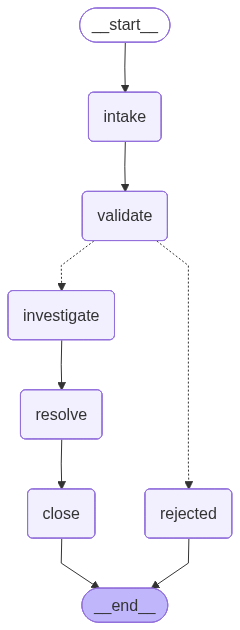

✅ Workflow graph rendered above


In [9]:
from IPython.display import Image, display

try:
    graph_image = app.get_graph().draw_mermaid_png()
    display(Image(graph_image))
    print("✅ Workflow graph rendered above")
except Exception as e:
    print(f"Graph rendering unavailable (install pygraphviz for full support): {e}")
    mermaid_str = app.get_graph().draw_mermaid()
    print("\nMermaid diagram source:")
    print(mermaid_str)

## Step 6: Helper — Print Workflow Summary

In [10]:
def print_workflow_summary(result: dict, complaint_num: int):
    """Pretty-print the final state after a complaint is processed."""
    sep = "═" * 60
    print(f"\n{sep}")
    print(f"  COMPLAINT #{complaint_num} — FINAL REPORT")
    print(sep)
    print(f"  Complaint    : {result.get('complaint', '')[:80]}..." \
          if len(result.get('complaint','')) > 80 \
          else f"  Complaint    : {result.get('complaint', '')}")
    print(f"  Category     : {result.get('category', 'N/A')}")
    print(f"  Status       : {result.get('status', 'N/A').upper()}")
    print(f"  Workflow path: {' → '.join(result.get('workflow_path', []))}")

    if result.get("is_valid") is False:
        print(f"  ❌ Rejected   : {result.get('rejection_reason', '')}")
    else:
        print(f"  ✅ Valid")
        print(f"  Resolution   : {result.get('resolution', 'N/A')}")
        print(f"  Effectiveness: {result.get('effectiveness_rating', 'N/A').upper()}")
        print(f"  Outcome      : {result.get('outcome', 'N/A')}")
        print(f"  Follow-up    : {'Yes — 30-day checkpoint' if result.get('follow_up_required') else 'No'}")
        print(f"  Escalation   : {'Yes' if result.get('requires_escalation') else 'No'}")
        print(f"  Closed at    : {result.get('closed_at', 'N/A')}")
    print(sep)


print("✅ Helper function defined")

✅ Helper function defined


## Step 7: Run Test Complaints

Five representative complaints — covering all five categories plus an intentionally invalid one.

In [11]:
test_complaints = [
    # 1. Portal — valid, good detail
    "The Downside Up portal at Hawkins Lab opens at different times each day. "
    "Yesterday it opened at 3 AM, today at 11 PM. How do I predict when it will appear next?",

    # 2. Monster — valid, good detail
    "Demogorgons near the Byers' house sometimes work together to flush out prey, "
    "but last Tuesday they started attacking each other. What triggers this behaviour change?",

    # 3. Psychic — valid, good detail
    "Eleven (El) can move objects with her mind but cannot lift anything heavier than ~20 kg. "
    "She's been practising daily at the Hawkins lab since Monday. Why is there a weight ceiling?",

    # 4. Environmental — valid
    "Every time a creature crosses over near Maple Street, the power lines buzz and "
    "streetlights flicker for exactly 4 minutes. Is there a physical cause for this?",

    # 5. Invalid — missing details (no who, when, or where)
    "Things in the Upside Down are weird and I don't like it. Fix it please.",
]

results = []

for i, complaint in enumerate(test_complaints, 1):
    print(f"\n{'#'*60}")
    print(f"# RUNNING COMPLAINT #{i}")
    print(f"{'#'*60}")

    initial_state: ComplaintState = {
        "complaint": complaint,
        "category": "",
        "missing_details": [],
        "is_valid": False,
        "validation_notes": "",
        "evidence": "",
        "investigation_summary": "",
        "resolution": "",
        "effectiveness_rating": "",
        "requires_escalation": False,
        "closed_at": "",
        "outcome": "",
        "follow_up_required": False,
        "workflow_path": [],
        "status": "pending",
        "rejection_reason": None,
    }

    result = app.invoke(initial_state)
    results.append(result)
    print_workflow_summary(result, i)

print("\n✅ All test complaints processed.")


############################################################
# RUNNING COMPLAINT #1
############################################################

[INTAKE] Processing complaint...
  Category     : portal
  Missing      : nothing

[VALIDATE] Applying Bloyce's Protocol rules...
  Verdict      : ✅ valid
  Notes        : The complaint references specific timing anomalies regarding the opening times of the Downside Up portal.

[INVESTIGATE] Gathering evidence...
  Evidence gathered (excerpt): ### Investigation Report: Downside Up Portal at Hawkins Lab

**Category:** Portal  
**Focus:** Temporal patterns, locati...

[RESOLVE] Generating resolution...
  Resolution   : Monitor the Downside Up portal daily at varying times, particularly during the hours of 3 AM and 11 PM, to gather data on its opening patterns.
  Effectiveness: MEDIUM
  Escalation   : No

[CLOSE] Closing complaint...


/var/folders/jw/vl_fr1t1247c25qj2rbsdxqr0000gn/T/ipykernel_32977/1759578628.py:35: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  closed_at = datetime.utcnow().isoformat() + "Z"


  Outcome      : RESOLVED
  Follow-up    : No
  Closed at    : 2026-05-11T15:42:26.125622Z

════════════════════════════════════════════════════════════
  COMPLAINT #1 — FINAL REPORT
════════════════════════════════════════════════════════════
  Complaint    : The Downside Up portal at Hawkins Lab opens at different times each day. Yesterd...
  Category     : portal
  Status       : CLOSED
  Workflow path: intake → validate → investigate → resolve → close
  ✅ Valid
  Resolution   : Monitor the Downside Up portal daily at varying times, particularly during the hours of 3 AM and 11 PM, to gather data on its opening patterns.
  Effectiveness: MEDIUM
  Outcome      : RESOLVED
  Follow-up    : No
  Escalation   : No
  Closed at    : 2026-05-11T15:42:26.125622Z
════════════════════════════════════════════════════════════

############################################################
# RUNNING COMPLAINT #2
############################################################

[INTAKE] Processing compla

## Step 8: Workflow Path Visualisation

Show each complaint's path through the state machine as an ASCII diagram.

In [12]:
def visualise_workflow_path(result: dict, complaint_num: int):
    """Print an ASCII workflow path diagram."""
    path = result.get("workflow_path", [])
    snippet = result.get("complaint", "")[:55]
    print(f"\nComplaint #{complaint_num}: \"{snippet}...\"")
    print("  " + " → ".join(f"[{step.upper()}]" for step in path))
    print(f"  Final status: {result.get('status', 'N/A').upper()}")


print("\n" + "═"*60)
print("  WORKFLOW PATH SUMMARY FOR ALL COMPLAINTS")
print("═"*60)
for i, r in enumerate(results, 1):
    visualise_workflow_path(r, i)


════════════════════════════════════════════════════════════
  WORKFLOW PATH SUMMARY FOR ALL COMPLAINTS
════════════════════════════════════════════════════════════

Complaint #1: "The Downside Up portal at Hawkins Lab opens at differen..."
  [INTAKE] → [VALIDATE] → [INVESTIGATE] → [RESOLVE] → [CLOSE]
  Final status: CLOSED

Complaint #2: "Demogorgons near the Byers' house sometimes work togeth..."
  [INTAKE] → [VALIDATE] → [INVESTIGATE] → [RESOLVE] → [CLOSE]
  Final status: CLOSED

Complaint #3: "Eleven (El) can move objects with her mind but cannot l..."
  [INTAKE] → [VALIDATE] → [INVESTIGATE] → [RESOLVE] → [CLOSE]
  Final status: CLOSED

Complaint #4: "Every time a creature crosses over near Maple Street, t..."
  [INTAKE] → [VALIDATE] → [INVESTIGATE] → [RESOLVE] → [CLOSE]
  Final status: CLOSED

Complaint #5: "Things in the Upside Down are weird and I don't like it..."
  [INTAKE] → [VALIDATE] → [REJECTED]
  Final status: REJECTED


## Step 9: Single Custom Complaint

Run your own complaint through the system.

In [13]:
custom_complaint = (
    "Since last week, the lights in the Hawkins High gym flicker every night at midnight "
    "and the temperature drops by 10°C for about two minutes. No creatures have been spotted yet. "
    "Reported by Coach Higgins."
)

custom_initial: ComplaintState = {
    "complaint": custom_complaint,
    "category": "",
    "missing_details": [],
    "is_valid": False,
    "validation_notes": "",
    "evidence": "",
    "investigation_summary": "",
    "resolution": "",
    "effectiveness_rating": "",
    "requires_escalation": False,
    "closed_at": "",
    "outcome": "",
    "follow_up_required": False,
    "workflow_path": [],
    "status": "pending",
    "rejection_reason": None,
}

print("Processing custom complaint...")
custom_result = app.invoke(custom_initial)
print_workflow_summary(custom_result, 0)
visualise_workflow_path(custom_result, 0)

Processing custom complaint...

[INTAKE] Processing complaint...
  Category     : environmental
  Missing      : nothing

[VALIDATE] Applying Bloyce's Protocol rules...
  Verdict      : ✅ valid
  Notes        : The complaint connects to observable physical phenomena, specifically the flickering lights and temperature drop.

[INVESTIGATE] Gathering evidence...
  Evidence gathered (excerpt): **Investigation Report: Downside Up Complaint Bureau**

**Category:** Environmental  
**Focus:** Power line activity, at...

[RESOLVE] Generating resolution...
  Resolution   : Initiate a nightly monitoring protocol for the Hawkins High gym to document the flickering lights and temperature fluctuations, while also installing temporary environmental sensors to gather data on the anomalies.
  Effectiveness: HIGH
  Escalation   : Yes ⚠️

[CLOSE] Closing complaint...
  Outcome      : ESCALATED
  Follow-up    : No
  Closed at    : 2026-05-11T15:43:50.476849Z

══════════════════════════════════════════════

/var/folders/jw/vl_fr1t1247c25qj2rbsdxqr0000gn/T/ipykernel_32977/1759578628.py:35: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  closed_at = datetime.utcnow().isoformat() + "Z"


---

## Summary

| Node | Responsibility |
|------|----------------|
| `intake` | Parse complaint → assign category, flag missing details |
| `validate` | Apply category-specific rules → accept or reject |
| `investigate` | Gather category-focused evidence → produce report |
| `resolve` | Generate specific resolution + effectiveness rating |
| `close` | Log outcome, set 30-day follow-up if low effectiveness |
| `rejected` | Terminal for invalid complaints — surfaces rejection reason |

All state travels in a single `ComplaintState` TypedDict, making every step fully auditable.